In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
# Copy and duplicate the Original dataset for data cleaning
df_clean = df.copy()
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Check Columns with null values
df_clean.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
# Use Mode for the Embarked Variable to fill the null values
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])
df_clean["Embarked"].isnull().sum()

np.int64(0)

In [8]:
# Fill Null Values on Age Variable with Medium
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Age"].isnull().sum()

np.int64(0)

In [11]:
# Drop Cabin Varibale - Too Many Null Values
df_clean = df_clean.drop(columns= "Cabin")
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Embarkerd
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,S


C:\Users\user\AppData\Local\Temp\ipykernel_2412\3376105375.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Survived", data=df_clean, palette="viridis")


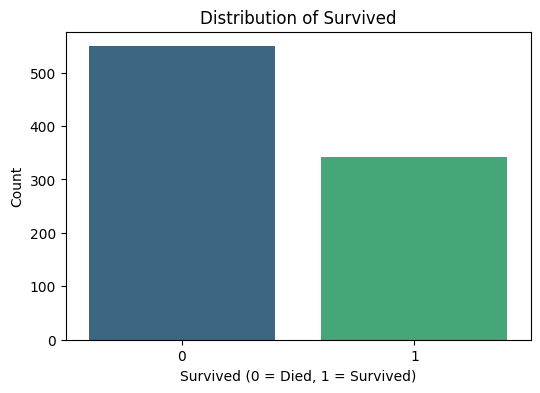

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [21]:
# Distribution of the Target Variable
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df_clean, palette="viridis")
plt.title("Distribution of Survived")
plt.xlabel("Survived (0 = Died, 1 = Survived)")
plt.ylabel("Count")
plt.show()

# Check exact numbers
print(df_clean["Survived"].value_counts())
print(df_clean["Survived"].value_counts(normalize=True))

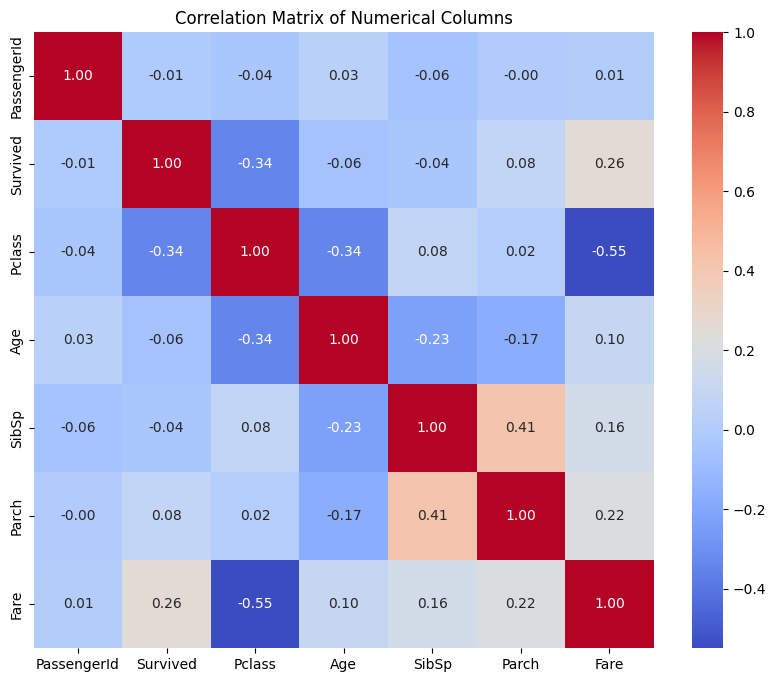

In [14]:
# Correlation Matrix of Numerical Columns
plt.figure(figsize= (10,8))
sns.heatmap(df_clean.corr(numeric_only= True), annot= True, cmap= "coolwarm", fmt= ".2f")
plt.title("Correlation Matrix of Numerical Columns")
plt.show()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
 11  Embarkerd    891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


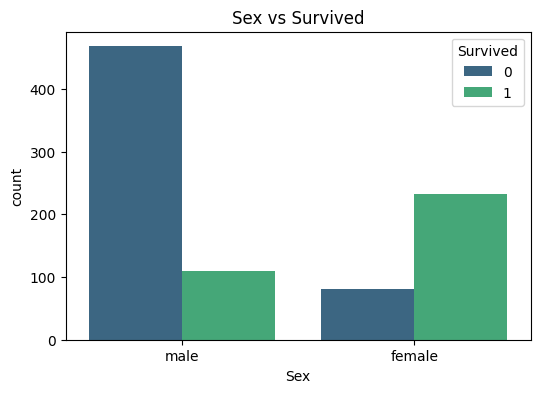

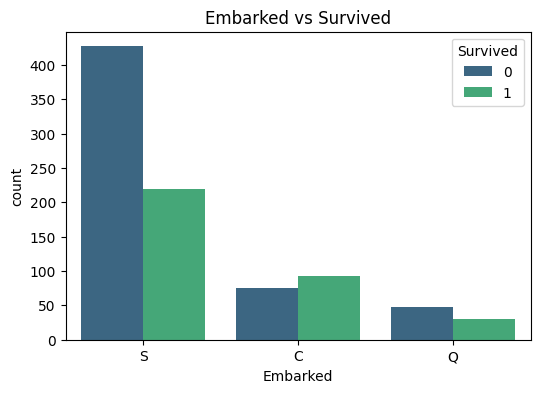

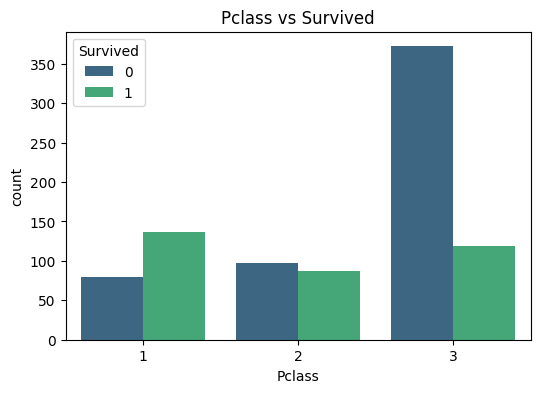

In [20]:
df_clean.info()

category_col = ["Sex", "Embarked", "Pclass"]

for col in category_col:
    plt.figure(figsize=(6,4))
    
    # ✅ Countplot is better for classification
    sns.countplot(x=col, hue="Survived", data=df_clean, palette="viridis")
    plt.title(f"{col} vs Survived")
    plt.show()

In [22]:
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Embarkerd
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,S


In [ ]:

df_clean = df_clean.drop(columns= ["PassengerId", "Name","Embarkerd","Ticket"])

In [28]:
df_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [29]:
# Label Encode 
df_clean["Sex"] = df_clean["Sex"].map({"male" : 0, "female" : 1})

In [30]:
df_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


In [ ]:
#Hot Label Encode
df_clean = pd.get_dummies(df_clean, columns=["Embarked"])
df_clean = df_clean.astype({col: int for col in df_clean.select_dtypes(include="bool").columns})

df_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


In [ ]:
# Feature Selection
from scipy.stats import f_oneway

numerical_cols = df_clean.select_dtypes(include=np.number).columns.tolist() 


if 'Survived' in numerical_cols:
    numerical_cols.remove('Survived')

print("Correlation with Survived:")
print(df[numerical_cols + ['Survived']].corr()['Survived'].sort_values(ascending=False).drop('Survived'))


# Check encoded columns too
print(df_clean[["Sex", "Embarked_C", "Embarked_Q", "Embarked_S", "Survived"]].corr()["Survived"])


Correlation with Survived:
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64
Sex           0.543351
Embarked_C    0.168240
Embarked_Q    0.003650
Embarked_S   -0.149683
Survived      1.000000
Name: Survived, dtype: float64


In [38]:
df_clean = df_clean.drop(columns= ["Parch", "SibSp","Age","Embarked_Q"])
df_clean.head()

,Survived,Pclass,Sex,Fare,Embarked_C,Embarked_S
0,0,3,0,7.2500,0,1
1,1,1,1,71.2833,1,0
2,1,3,1,7.9250,0,1
3,1,1,1,53.1000,0,1
4,0,3,0,8.0500,0,1


In [39]:
# Feature Scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


df_clean["Pclass"] = scaler.fit_transform(df_clean[["Pclass"]])
df_clean["Fare"] = scaler.fit_transform(df_clean[["Fare"]])


df_clean.head()


,Survived,Pclass,Sex,Fare,Embarked_C,Embarked_S
0,0,1.0,0,0.014151,0,1
1,1,0.0,1,0.139136,1,0
2,1,1.0,1,0.015469,0,1
3,1,0.0,1,0.103644,0,1
4,0,1.0,0,0.015713,0,1


In [47]:
df_clean["Pclass"] = df["Pclass"]

In [ ]:
df_clean.head(100)

,Survived,Pclass,Sex,Fare,Embarked_C,Embarked_S
0,0,3,0,0.014151,0,1
1,1,1,1,0.139136,1,0
2,1,3,1,0.015469,0,1
3,1,1,1,0.103644,0,1
4,0,3,0,0.015713,0,1
...,...,...,...,...,...,...
95,0,3,0,0.015713,0,1
96,0,1,0,0.067640,1,0
97,1,1,0,0.123667,1,0
98,1,2,1,0.044893,0,1


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df_clean.drop(columns=["Survived"])
y = df_clean["Survived"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
Accuracy: 0.7653631284916201
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       105
           1       0.70      0.77      0.73        74

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.76       179
weighted avg       0.77      0.77      0.77       179



In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       105
           1       0.76      0.78      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.81      0.80       179
weighted avg       0.81      0.81      0.81       179



In [52]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Results:
Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [53]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Random Forest":       accuracy_score(y_test, y_pred_rf),
    "XGBoost":             accuracy_score(y_test, y_pred_xgb)
}

for model, score in results.items():
    print(f"{model}: Accuracy = {score:.4f}")

Logistic Regression: Accuracy = 0.7654
Random Forest: Accuracy = 0.7989
XGBoost: Accuracy = 0.8101
